# Diabetes Prediction Model

The goal of this analysis is to predict diabetes risk by using patient features. \
As the dataset is of medical nature, the focus lies on minimizing the recall to mitigate misclassification of patients who actually have diabetes.

## Load Libraries

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

## Load Dataset

The dataset incorporates demographic variables like
- gender
- age

as well as various variables which can be helpful in predicting whether a patient is likely to have diabetes:
- hypertension
- heart disease
- smoking history
- bmi
- HbA1c level
- blood glucose level

The target variable is an encoded diabetes variable: 0 if the patient has no diabetes, 1 if the patient has diabetes.

In [2]:
df = pd.read_csv("../data/diabetes_prediction_dataset.csv")

print(df.shape)
print(df.columns)
df.head()

(100000, 9)
Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


### Check for Duplicates

The dataset is inspected for and stripped of duplicates.

In [4]:
df.info()
print(df.isna().sum())
print("Duplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64
Duplicates: 3854


In [5]:
df_nodupes = df.drop_duplicates().copy()

In [ ]:
df_nodupes.describe()

## Encode Variables

To make variables such as _gender_ or _smoking history_ useable they have to be converted into numerical values. \
Therefore, gender was encoded by a simple 0/1 encoding and smoking history was encoded by a one-hot-encoding because there is no clear ordinal ranking of the categories. 

In [6]:
le = LabelEncoder()

df_nodupes["gender_enc"] = le.fit_transform(df_nodupes["gender"])

df_nodupes = pd.get_dummies(df_nodupes, columns=["smoking_history"], drop_first=True)

bool_cols = df_nodupes.select_dtypes(include="bool").columns

df_nodupes[bool_cols] = df_nodupes[bool_cols].astype(int)

df_nodupes.head()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_enc,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,Female,80.0,0,1,25.19,6.6,140,0,0,0,0,0,1,0
1,Female,54.0,0,0,27.32,6.6,80,0,0,0,0,0,0,0
2,Male,28.0,0,0,27.32,5.7,158,0,1,0,0,0,1,0
3,Female,36.0,0,0,23.45,5.0,155,0,0,1,0,0,0,0
4,Male,76.0,1,1,20.14,4.8,155,0,1,1,0,0,0,0


## Definition of Feature and Target 

The next step is to compromise the full dataset into feature and target matrices. \
To do that, feature columns are chosen and the X (feature) matrix is created and the y (target) matrix is chosen as the _diabetes_ column.

In [7]:
X_columns = [
    "gender_enc",
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level",
    "smoking_history_current",
    "smoking_history_ever",
    "smoking_history_former",
    "smoking_history_never",
    "smoking_history_not current"
    ]

X = df_nodupes[X_columns].copy()
X.head()

,gender_enc,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,0,80.0,0,1,25.19,6.6,140,0,0,0,1,0
1,0,54.0,0,0,27.32,6.6,80,0,0,0,0,0
2,1,28.0,0,0,27.32,5.7,158,0,0,0,1,0
3,0,36.0,0,0,23.45,5.0,155,1,0,0,0,0
4,1,76.0,1,1,20.14,4.8,155,1,0,0,0,0


In [8]:
y = df_nodupes["diabetes"].copy()
y.head()

0    0
1    0
2    0
3    0
4    0
Name: diabetes, dtype: int64

### Check Dataset Balancing

In [29]:
y.value_counts(normalize=True)

diabetes
0    0.91178
1    0.08822
Name: proportion, dtype: float64

To resolve the imbalance of the target class _diabetes_, the models will be trained with balanced class weights. That is important because otherwise the model could dummy-classify as 0 (no diabetes) every time and have an accuracy score of 0.91178. Because of that the recall score would be below the balanced models. 

## Train-Test-Split 

A train and test split is created to train the models on part of the data and test the efficiency of the models with the unseen test split. 

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Pipeline

Pipelines are created to enable a fluent workflow with the 3 classification models: Logistic Regression, Decision Tree, Random Forest. \
The hyperparameters are already plugged in from the hyperparameter testing below. \
The Dummy model predicts the most frequent value of the target variable, which is 0. It's included to show that the other models are better in predicting diabetes outcomes.

In [81]:
models = {
    "Dummy": Pipeline([
        ("dummy", DummyClassifier(strategy="most_frequent"))
    ]),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(C=0.1, penalty="l2", max_iter=5000, solver="liblinear", class_weight="balanced"))
    ]),
    "Decision Tree": Pipeline([
        ("dt", DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("rf", RandomForestClassifier(max_depth=15, n_estimators=200, class_weight="balanced", random_state=42))
    ])
}

## Hyperparameter Testing

To assist the decision of the hyperparameter choice, a grid search cross validation is performed for the 3 classification models.

### Logistic Regression

C: Regularization parameter (Bias-Variance Tradeoff). Regulates the fit of the model with respect to the data.\
penalty: If the penalty should be absolute (l1) or quadratic (l2). \
solver: Algorithm used to optimize the calculation of model parameters.

In [31]:
param_grid = {
    "lr__C": [0.01, 0.1, 1, 10, 100],
    "lr__penalty": ["l1", "l2"],
    "lr__solver": ["liblinear"]
}

grid = GridSearchCV(
    models["Logistic Regression"],
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'lr__C': 0.01, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Best score: 0.9623063281423312


### Decision Tree

max_depth: The maximum number of layers the Decision Tree is allowed to facilitate.

In [ ]:
param_grid = {
    "dt__max_depth": [3, 5, 10, 11, 12]
}

grid = GridSearchCV(
    models["Decision Tree"],
    param_grid,
    cv=5,
    scoring="roc_auc"
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'dt__max_depth': 10}
Best score: 0.9732473236313741


### Random Forest

max_depth: The maximum number of layers the Random Forest Trees are allowed to facilitate. \
n_estimators: Number of Decision Trees in the Random Forest.

In [26]:
param_grid = {
    "rf__max_depth": [10, 15, 16],
    "rf__n_estimators": [200]
}

grid = GridSearchCV(
    models["Random Forest"],
    param_grid,
    cv=5,
    scoring="roc_auc"
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'rf__max_depth': 15, 'rf__n_estimators': 200}
Best score: 0.9744692589133223


## Model Training

After finding the hyperparameters the models are being trained on the training data (X_train, y_train). First, the models are trained with the default threshold of 0.5 and afterwards with custom thresholds, which are designed to keep the precision (minimize false positives) ≈ 0.4 and maximize the recall (minimize false negatives). That is important because misdiagnosing actual diabetes patients is more severe than misdiagnosing non-diabetes patients.

Going hand in hand is the evaluation of the models by using scores like Accuracy, Precision, Recall and ROC-AUC. Furthermore, confusion matrices were calculated in this step as well to show the classification efficiencies of the models (Visualizations are further below).

In [84]:
results = []
results_prec = []
conf_matrices = []
conf_matrices_custom = []

thresholds = {
    "Logistic Regression": 0.462,
    "Decision Tree": 0.48,
    "Random Forest": 0.315
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)

    # model training
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    # scores
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    # confusion matrix
    conf_matrices.append({
        "Model": name,
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    })

    # custom thresholds
    if name in thresholds:
        t = thresholds[name]
        y_pred_custom = (y_prob >= t).astype(int)

        # scores
        results_prec.append({
            "Model": name,
            "Threshold": t,
            "Accuracy": accuracy_score(y_test, y_pred_custom),
            "Precision": precision_score(y_test, y_pred_custom, zero_division=0),
            "Recall": recall_score(y_test, y_pred_custom, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, y_prob)
        })

    # confusion matrix
    conf_matrices_custom.append({
        "Model": name,
        "Confusion Matrix": confusion_matrix(y_test, y_pred_custom)
    })

In [85]:
results_df1 = pd.DataFrame(results).round(3)
results_df2 = pd.DataFrame(results_prec).round(3)

print("--- Threshold = 0.5 ---\n", results_df1)
print("\n--- Custom Thresholds ---\n", results_df2)

--- Threshold = 0.5 ---
                  Model  Accuracy  Precision  Recall  ROC-AUC
0                Dummy     0.912      0.000   0.000    0.500
1  Logistic Regression     0.884      0.425   0.880    0.960
2        Decision Tree     0.881      0.419   0.915    0.970
3        Random Forest     0.929      0.564   0.837    0.973

--- Custom Thresholds ---
                  Model  Threshold  Accuracy  Precision  Recall  ROC-AUC
0  Logistic Regression      0.462     0.872      0.400   0.896    0.960
1        Decision Tree      0.480     0.881      0.419   0.915    0.970
2        Random Forest      0.315     0.871      0.400   0.925    0.973


The results of the classification models with default and custom thresholds shows that by default the recall is smaller relatively, but the overall accuracies of the models are higher than with custom thresholds. If the thresholds are customized to maximize the recalls while not letting the precisions drop off under 0.4 there arises a tendency that the Random Forest model is suited best for this kind of classification task with medical data and a focus on the recall score because the recall score is the highest. The accuracy scores drop because of the tradeoff between maximal accuracy and recall. 

With regards to the Dummy model the precision and recall scores are 0 due to the prediction of no diabetes, even in actual diabetes patients. And though the accuracy score is high, it is not meaningful when dealing with imbalanced data.

## Visualizations

Confusion Matrices are depicted for every classification model and for both default and custom thresholds. The Matrices show that after customizing the thresholds accordingly, the False Negatives (Predicted Label - No Diabetes, True Label - Diabetes) drop. This is important for the models because patients who have diabetes which are not classified as such pose a greater threat than patients which don't have diabetes but are classified as diabetes patients. Although this would require more testing of the patients, it is better than not detecting diabetes in actual diabetes patients.

### Confusion Matrices for Default Threshold

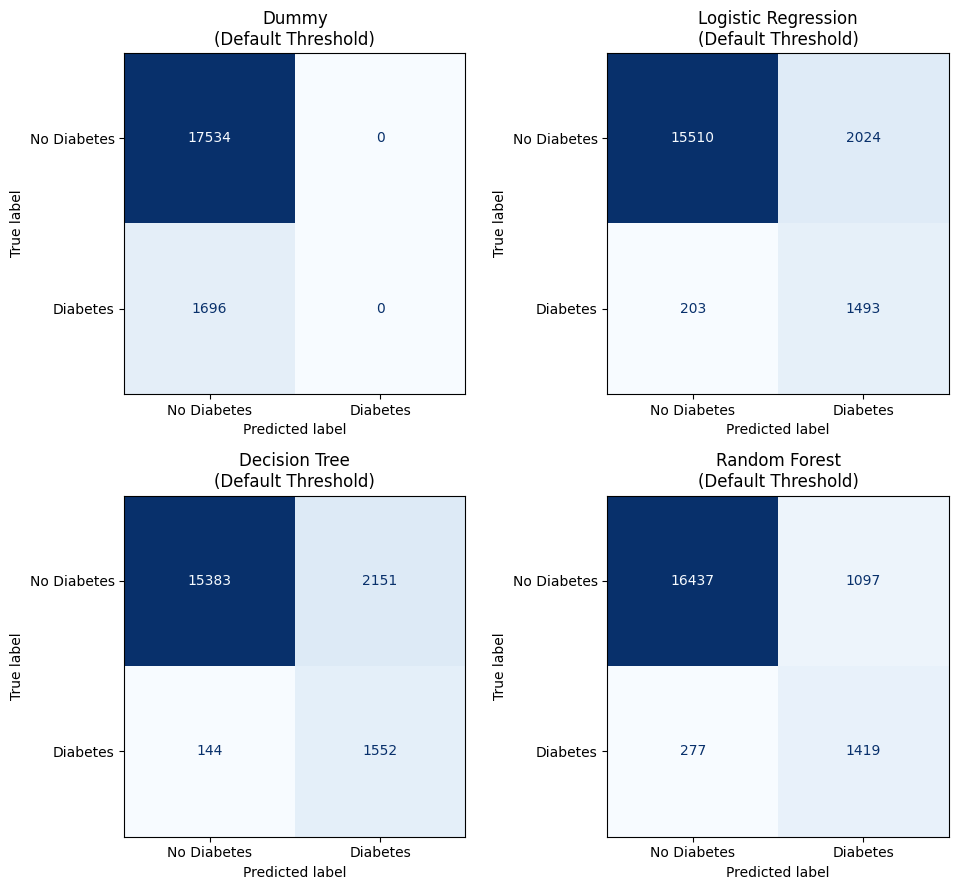

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

axes = axes.flatten()

for i, item in enumerate(conf_matrices):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=item["Confusion Matrix"],
        display_labels=["No Diabetes", "Diabetes"]
    )
    
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)

    axes[i].set_title(f"{item['Model']}\n(Default Threshold)")

plt.tight_layout()
plt.show()

### Confusion Matrices for Custom Threshold

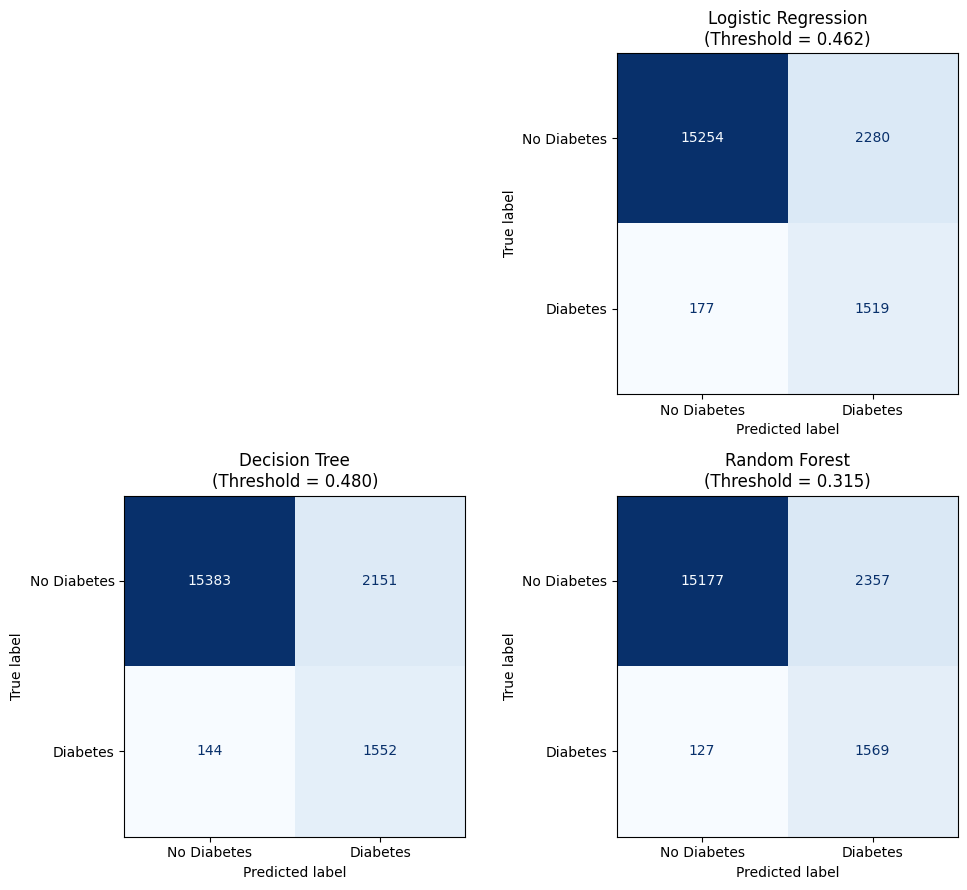

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

axes = axes.flatten()

for i, item in enumerate(conf_matrices_custom):
    if item["Model"] in thresholds:
        disp = ConfusionMatrixDisplay(
            confusion_matrix=item["Confusion Matrix"],
            display_labels=["No Diabetes", "Diabetes"]
        )
    
        disp.plot(ax=axes[i], cmap="Blues", colorbar=False)

        t = thresholds[item["Model"]]

        axes[i].set_title(f"{item['Model']}\n(Threshold = {t:.3f})")


fig.delaxes(axes[0])

plt.tight_layout()
plt.show()

### ROC-Curves

Additionaly, ROC-Curves show the efficiency of the models with respect to classification of diabetes patients. 

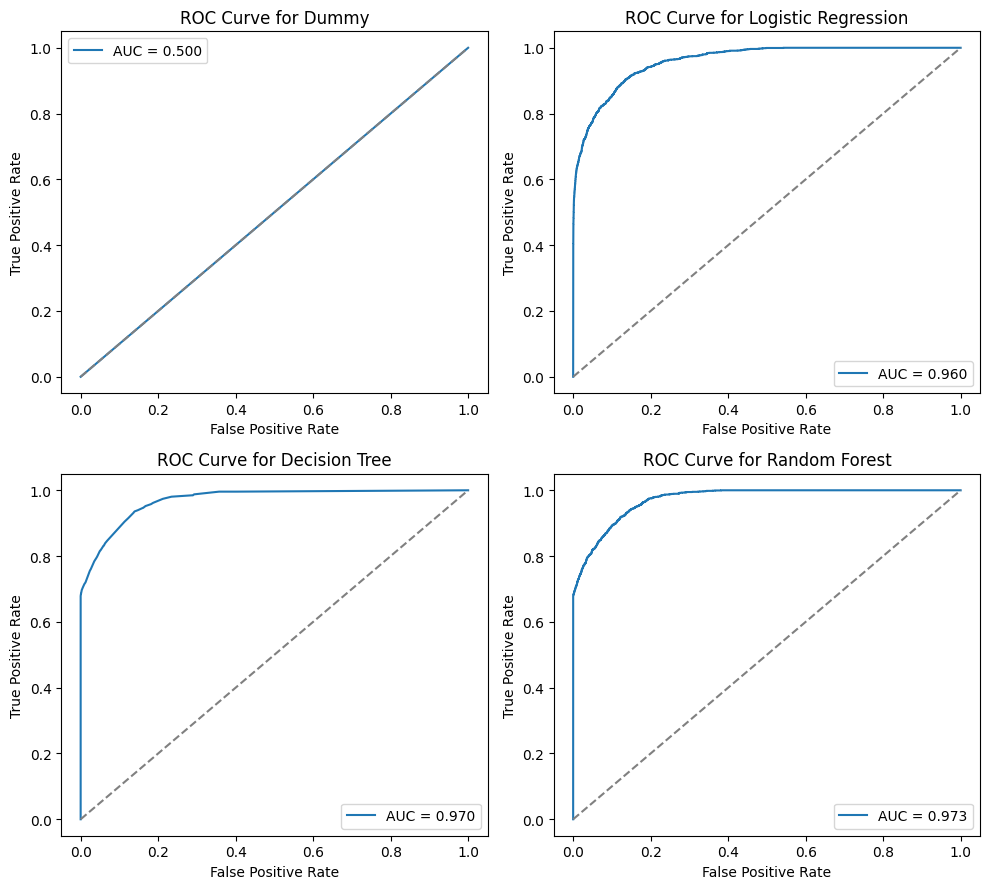

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()

for i, (name, pipe) in enumerate(models.items()):
    pipe.fit(X_train, y_train)

    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    axes[i].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    axes[i].plot([0, 1], [0, 1], linestyle="--", color="gray")

    axes[i].set_xlabel("False Positive Rate")
    axes[i].set_ylabel("True Positive Rate")
    axes[i].set_title(f"ROC Curve for {name}")
    axes[i].legend()

plt.tight_layout()
plt.show()

The Random Forest model has the highest AUC value which corresponds with the best classification of diabetes patients as having diabetes. This is independent of the threshold because the ROC-Curve iterates over all possible thresholds. The Dummy model achieves an AUC of 0.5, indicating random classification performance. 

### Decision Tree Visualization

To further understand how the classifications are made, the underlying Decision Tree is shown below.

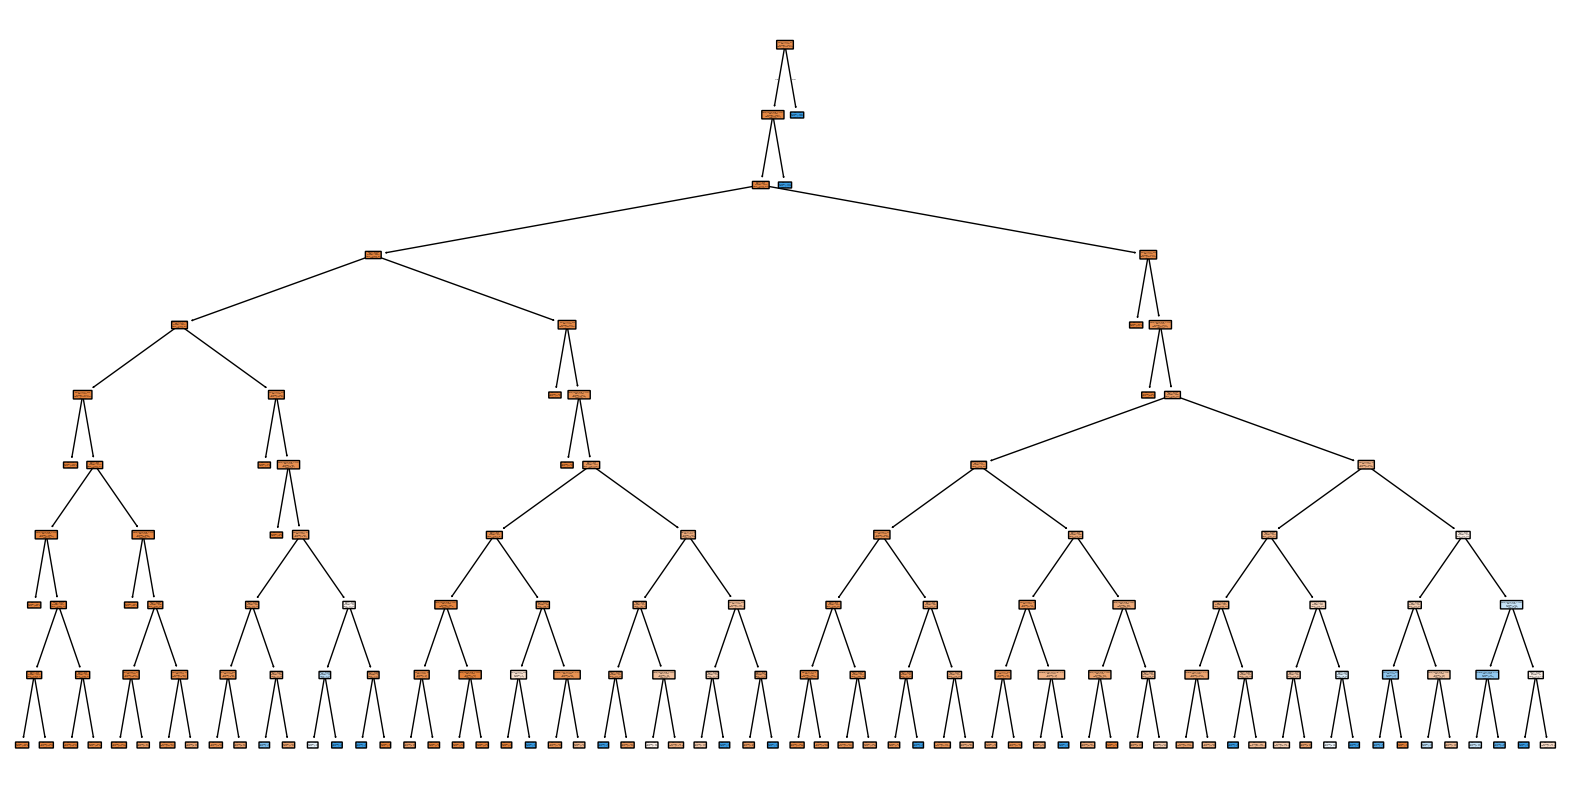

In [19]:
plt.figure(figsize=(20,10))

plot_tree(
    models["Decision Tree"].named_steps["dt"],
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True
)

plt.show()

## Feature Importance

The classification models use features to determine how they classify a patient. Not every feature has the same weight with regards to the decision. This is analysed with the visualizations below to examine which features play the main role in determining a diabetes patient.

In [20]:
lr_model = models["Logistic Regression"].named_steps["lr"]

lr_coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr_model.coef_[0]
}).sort_values("coefficient", ascending=True)

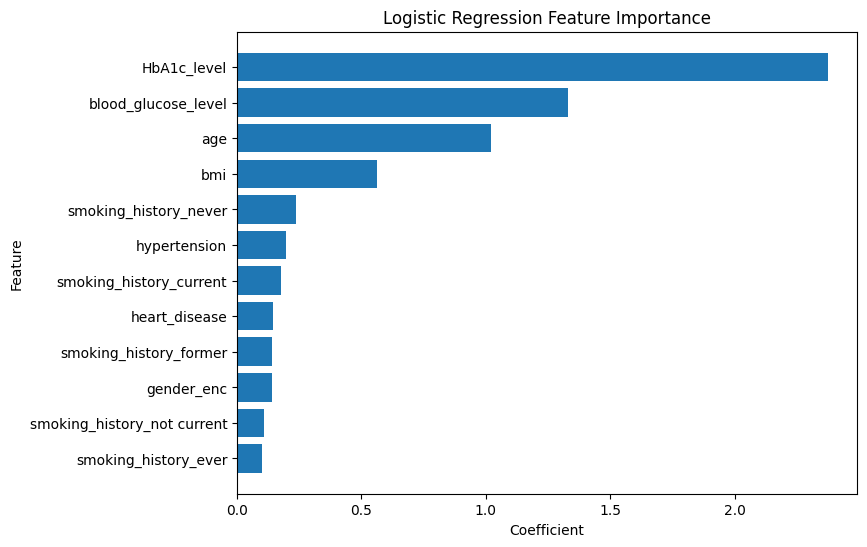

In [ ]:
plt.figure(figsize=(8,6))

plt.barh(lr_coefficients["feature"], lr_coefficients["coefficient"])
plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

In [22]:
dt_model = models["Decision Tree"].named_steps["dt"]

dt_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": dt_model.feature_importances_
}).sort_values("importance", ascending=True)

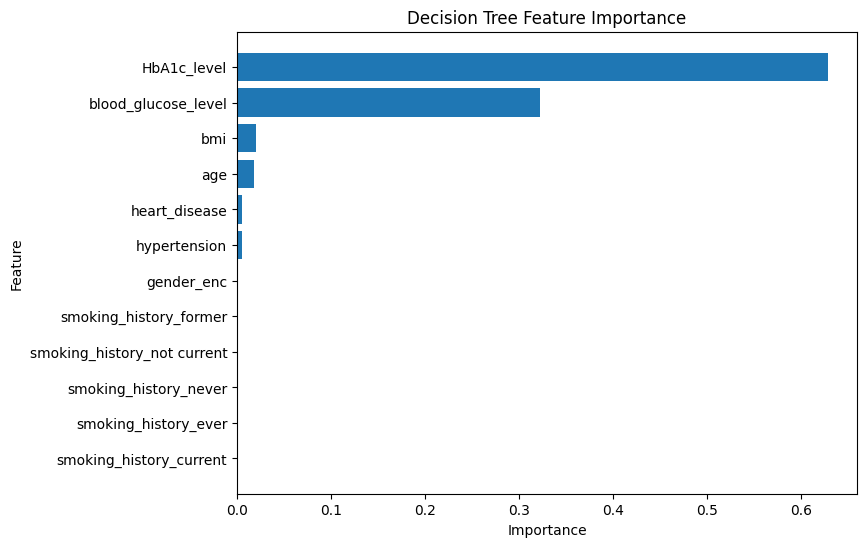

In [ ]:
plt.figure(figsize=(8,6))

plt.barh(dt_importances["feature"], dt_importances["importance"])
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [24]:
rf_model = models["Random Forest"].named_steps["rf"]

rf_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=True)

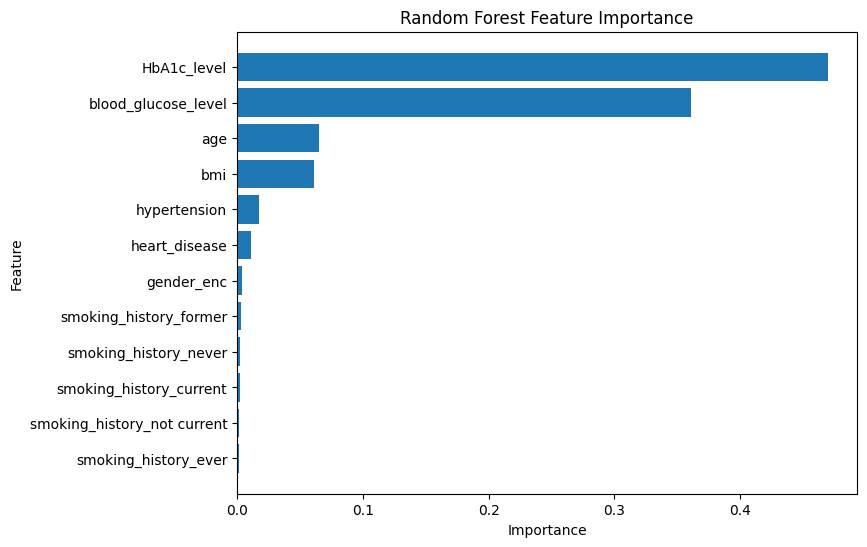

In [103]:
plt.figure(figsize=(8,6))

plt.barh(rf_importances["feature"], rf_importances["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The consensus of the models indicates that the HbA1c level and blood glucose level are the most important features for the classification of diabetes. Age and BMI seem like influential variables as well. Noticable is, that the Logistic Regression model incorporates every feature to some extent, while the Tree models give some features diminishing influence. 

## Summary

Overall, Random Forest achieved the highest recall after threshold tuning, making it the most suitable model for this specific medical application. \
The most meaningful variables for the classification of diabetes patients seem to be HbA1c and blood glucose levels as well as age and BMI. 

The Random Forest model with a custom threshold was selected as the final model due to its superior recall performance.

## Limitations

The Diabetes Prediction Model is limited by the following:
- Dataset may not represent real-world distribution
- No temporal data
- No clinical validation

## Future Work

Possible extensions include:
- Use real clinical data
- Try gradient boosting (XGBoost)